In [1]:
import chromadb

In [2]:
client = chromadb.Client()

In [3]:
client

In [4]:

#* En chroma una 'colección' funciona como una tabla temática solo se guarda textos relacionados con el tema especifico.
#* En este ejemplo usaremos una colección de 'políticas'

collection = client.get_or_create_collection(
    name="banco_andino_politicas_credito",
    metadata={"tema": "politicas_credito", "idioma": "es"}
)

In [5]:
collection

Collection(name=banco_andino_politicas_credito)

In [6]:

#* Definimos los documentos que vamos a insertar en la colección

#* Cada documento representa una política o línea de producto del Banco Andino
#* -crédito de consumo
#* -crédito con descuento de plantilla.
#* -crédito hipotecario
#* -crédito para pymes
#* -política general de riesgo

In [7]:
documentos_banco_andino = [
    {
        "id": "consumo_clasico",
        "texto": """
Crédito de consumo clásico dirigido a personas asalariadas con al menos 12 meses de estabilidad laboral.
Monto: USD 1,000 a 10,000. Plazo: 6 a 36 meses.
Requisitos: comprobante de ingresos, sin mora mayor a 30 días en los últimos 12 meses.
La cuota mensual no debe superar el 35% del ingreso neto del cliente.
""",
    },
    {
        "id": "nomina_convenio",
        "texto": """
Crédito con descuento por nómina para empleados de empresas con convenio vigente con el banco.
No requiere codeudor. Antigüedad mínima: 6 meses.
Monto máximo: hasta 8 veces el salario neto mensual.
El pago se realiza vía deducción automática en planilla.
""",
    },
    {
        "id": "hipotecario_primera_vivienda",
        "texto": """
Crédito hipotecario para primera vivienda.
Financia hasta el 80% del valor de tasación del inmueble. Plazo hasta 20 años.
Requisitos: enganche mínimo del 20%, sin registros negativos en los últimos 24 meses.
Las obligaciones mensuales totales (incluida la hipoteca) no deben superar el 40% del ingreso familiar neto.
""",
    },
    {
        "id": "pyme_capital_trabajo",
        "texto": """
Crédito PYME Capital de Trabajo para empresas con al menos 2 años de operación formal.
Montos desde USD 5,000 hasta USD 200,000. Plazo hasta 24 meses.
Requiere estados financieros, flujo de caja proyectado y, según el riesgo, garantías reales o fideicomisos.
""",
    },
    {
        "id": "politica_riesgo_general",
        "texto": """
Política general de riesgo de crédito.
Se evalúan estabilidad laboral o del negocio, nivel de endeudamiento, score interno y externo,
y comportamiento histórico con el banco.
Solicitudes con endeudamiento total superior al 45% del ingreso neto se consideran solo de forma excepcional.
No se aprueban créditos con moras activas mayores a 90 días al momento de la evaluación.
""",
    },
]

In [8]:

#* Preparamos las listas de IDs y textos

#* Chroma espera que, al agregar los documentos, le pasemos:
#* - una lista de IDs únicos (ids=...)
#* - una lista de textos (documents=...)

ids = [doc['id'] for doc in documentos_banco_andino]
texts = [doc['texto'] for doc in documentos_banco_andino]

collection.add(
    ids=ids,
    documents=texts
)

In [9]:
print("Colección creada correctamente")
print(f"Número de documentos en la colección: {collection.count()}")

Colección creada correctamente
Número de documentos en la colección: 5


In [10]:
collection.peek()

{'ids': ['consumo_clasico',
  'nomina_convenio',
  'hipotecario_primera_vivienda',
  'pyme_capital_trabajo',
  'politica_riesgo_general'],
 'embeddings': array([[ 0.02188946,  0.04819354, -0.07701477, ..., -0.05017765,
         -0.00977983, -0.03246012],
        [-0.01487017,  0.05564198, -0.04528982, ...,  0.08156134,
          0.05881379, -0.05116512],
        [ 0.00569541,  0.05624285, -0.08049811, ...,  0.06674723,
          0.01984693, -0.04817226],
        [-0.00191686,  0.00303889, -0.02189822, ..., -0.09093931,
          0.07315933, -0.080786  ],
        [-0.04108548,  0.02854864, -0.02662269, ...,  0.00633242,
          0.04045399, -0.0885282 ]], shape=(5, 384)),
 'documents': ['\nCrédito de consumo clásico dirigido a personas asalariadas con al menos 12 meses de estabilidad laboral.\nMonto: USD 1,000 a 10,000. Plazo: 6 a 36 meses.\nRequisitos: comprobante de ingresos, sin mora mayor a 30 días en los últimos 12 meses.\nLa cuota mensual no debe superar el 35% del ingreso neto d

In [11]:

#* Consulta por similitud y visualización de resultados

In [12]:
def imprimir_resultados(resultados, titulo="Resultados"):
    print("\n" + "="*90)
    print(titulo)
    print("="*90)
    
    docs = resultados.get("documents", [[]])[0]
    ids = resultados.get("ids", [[]])[0]
    dists = resultados.get("distances", [[]])[0]
    
    if not docs:
        print("No se encontraron resultados.")
        return
    
    for rank, (doc_id, doc_text, dist) in enumerate(zip(ids, docs, dists), start=1):
        snippet = doc_text.strip().replace("\n", " ")
        if len(snippet) > 200:
            snippet = snippet[:197] + "..."
        
        print(f"Top {rank} | ID: {doc_id:<26} | Distancia: {dist:.4f}")
        print(f"         Snippet: {snippet}")
    
    print("Nota: menor distancia = mayor similitud semántica.")

In [13]:

#* Realizamos una consulta de ejemplo
consulta_rel_1 = "¿Cuál es el porcentaje máximo del ingreso que puede destinarse a la cuota mensual?"
res_rel_1 = collection.query(
    query_texts=[consulta_rel_1],
    n_results=3
)
imprimir_resultados(res_rel_1, titulo="Consulta: Porcentaje máximo del ingreso para cuota mensual")


Consulta: Porcentaje máximo del ingreso para cuota mensual
Top 1 | ID: nomina_convenio            | Distancia: 0.8790
         Snippet: Crédito con descuento por nómina para empleados de empresas con convenio vigente con el banco. No requiere codeudor. Antigüedad mínima: 6 meses. Monto máximo: hasta 8 veces el salario neto mensual....
Top 2 | ID: hipotecario_primera_vivienda | Distancia: 1.0978
         Snippet: Crédito hipotecario para primera vivienda. Financia hasta el 80% del valor de tasación del inmueble. Plazo hasta 20 años. Requisitos: enganche mínimo del 20%, sin registros negativos en los últimos...
Top 3 | ID: consumo_clasico            | Distancia: 1.1509
         Snippet: Crédito de consumo clásico dirigido a personas asalariadas con al menos 12 meses de estabilidad laboral. Monto: USD 1,000 a 10,000. Plazo: 6 a 36 meses. Requisitos: comprobante de ingresos, sin mor...
Nota: menor distancia = mayor similitud semántica.


In [14]:
consulta_rel_2 = "¿Cuál es el monto máximo que puedo solicitar con descuento por nómina?"
res_rel_2 = collection.query(
    query_texts=[consulta_rel_2],
    n_results=3
)
imprimir_resultados(res_rel_2, titulo="Consulta: Monto máximo crédito con descuento por nómina")


Consulta: Monto máximo crédito con descuento por nómina
Top 1 | ID: nomina_convenio            | Distancia: 0.6704
         Snippet: Crédito con descuento por nómina para empleados de empresas con convenio vigente con el banco. No requiere codeudor. Antigüedad mínima: 6 meses. Monto máximo: hasta 8 veces el salario neto mensual....
Top 2 | ID: hipotecario_primera_vivienda | Distancia: 1.0327
         Snippet: Crédito hipotecario para primera vivienda. Financia hasta el 80% del valor de tasación del inmueble. Plazo hasta 20 años. Requisitos: enganche mínimo del 20%, sin registros negativos en los últimos...
Top 3 | ID: politica_riesgo_general    | Distancia: 1.0996
         Snippet: Política general de riesgo de crédito. Se evalúan estabilidad laboral o del negocio, nivel de endeudamiento, score interno y externo, y comportamiento histórico con el banco. Solicitudes con endeud...
Nota: menor distancia = mayor similitud semántica.


In [15]:
consulta_no_rel_1 = "¿Cuántas unidades de zapatillas vendimos en la tienda el mes pasado?"
res_no_rel_1 = collection.query(
    query_texts=[consulta_no_rel_1],
    n_results=3
)
imprimir_resultados(res_no_rel_1, titulo="Consulta no relacionada: Ventas de zapatillas")


Consulta no relacionada: Ventas de zapatillas
Top 1 | ID: nomina_convenio            | Distancia: 1.0885
         Snippet: Crédito con descuento por nómina para empleados de empresas con convenio vigente con el banco. No requiere codeudor. Antigüedad mínima: 6 meses. Monto máximo: hasta 8 veces el salario neto mensual....
Top 2 | ID: hipotecario_primera_vivienda | Distancia: 1.1120
         Snippet: Crédito hipotecario para primera vivienda. Financia hasta el 80% del valor de tasación del inmueble. Plazo hasta 20 años. Requisitos: enganche mínimo del 20%, sin registros negativos en los últimos...
Top 3 | ID: politica_riesgo_general    | Distancia: 1.2104
         Snippet: Política general de riesgo de crédito. Se evalúan estabilidad laboral o del negocio, nivel de endeudamiento, score interno y externo, y comportamiento histórico con el banco. Solicitudes con endeud...
Nota: menor distancia = mayor similitud semántica.


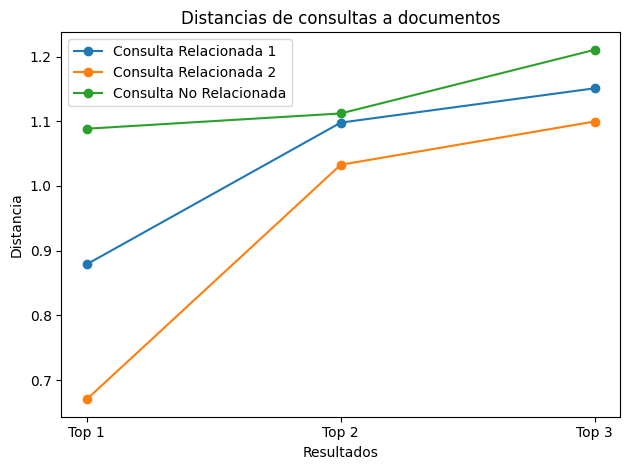

In [16]:
try:
    import matplotlib.pyplot as plt
    
    d1 = res_rel_1['distances'][0]
    d2 = res_rel_2['distances'][0]
    d3 = res_no_rel_1['distances'][0]
    
    plt.figure()
    plt.title("Distancias de consultas a documentos")
    plt.plot(range(1, len(d1)+1), d1, marker='o', label='Consulta Relacionada 1')
    plt.plot(range(1, len(d2)+1), d2, marker='o', label='Consulta Relacionada 2')
    plt.plot(range(1, len(d3)+1), d3, marker='o', label='Consulta No Relacionada')
    
    plt.xticks([1, 2, 3], ['Top 1', 'Top 2', 'Top 3'])
    
    plt.xlabel("Resultados")
    plt.ylabel("Distancia")
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("No se pudo generar la gráfica de distancias:", str(e))